
## Exploratory data analysis


### Data understanding and assessment
Before any analysis, we need to understand what we have: data types, missing values, duplicates, and basic distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('./data/hotel_bookings.csv')

In [ ]:
print('Dataset overview')
print(f'Rows : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Date range : Jul 2015 - Aug 2017') # from Kaggle dataset description
print(f'Hotels : {df["hotel"].unique()}')
print()
df.dtypes

Dataset overview
Rows : 119,390
Columns : 32
Date range : Jul 2015 - Aug 2017
Hotels : ['Resort Hotel' 'City Hotel']



hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': (missing / len(df) * 100).round(2),
    'dtype': df[missing.index].dtypes
}).sort_values('missing_pct', ascending=False)

print('Missing values')
print(missing)

Missing values
          missing_count  missing_pct    dtype
company          112593        94.31  float64
agent             16340        13.69  float64
country             488         0.41   object
children              4         0.00  float64


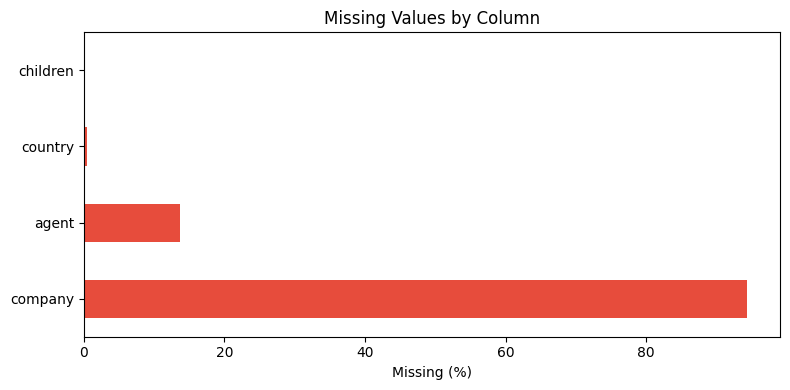

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
missing['missing_pct'].plot(kind='barh', ax=ax, color='#E74C3C')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.savefig('./visuals/missing_values.png', bbox_inches='tight')
plt.show()

Accordign to the source of the dataset "company" is the company/entity that made the booking or responsible for paying the booking, and "agent" is the travel agency that made the booking. They both have "NULL" values; however, these do not represent a missing value but rather a "not applicable "value". So of a guest made a booking independently, then agent and company will both contain a "NULL" value. Dropping the column would not be the way to go for this.

In [12]:
# checking for duplicates\
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)')

Duplicate rows: 31,994 (26.80%)


In [13]:
# descriptive statistics
print('Descriptive statistics')
df.describe().T.round(2)

Descriptive statistics


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


- adr cannot be negative because its a spending rate, definitly has outliers because why is max 5.4k
- company and agent are IDs so they shouldnt be treated as numbers -> need to convert them to str
- seems to be outliers in days_in_waiting becauyse the 75% is 0 and max is 391
- adults max also seems to be an outlier because 55 is very high for one booking 

### Data cleaning
According to the source, the following needs to be accounted for:
- `children`, `country`, `agent`, `company` have real null values
- `NULL` strings in `agent` and `company` mean "not applicable" not missing
- Rows with 0 adults, 0 children, and 0 babies are phantom bookings
- `adr` has negative values which are data errors

In [14]:
# fix children and country null values --> null children = 0 and null country = 'Unknown'
df_clean = df.copy()
df_clean['children'] = df_clean['children'].fillna(0).astype(int)
df_clean['country'] = df_clean['country'].fillna('Unknown')

print(f'children nulls filled: {df["children"].isnull().sum()}') 
print(f'country nulls filled : {df["country"].isnull().sum()}')

children nulls filled: 4
country nulls filled : 488


In [ ]:
# check how many phantom bookings there are
phantom_mask = (df_clean['adults'] == 0) & (df_clean['children'] == 0) & (df_clean['babies'] == 0)
print(f'Phantom bookings to remove: {phantom_mask.sum()}')
df_clean = df_clean[~phantom_mask]

Phantom bookings to remove: 180
Removed


In [17]:
# fix the agent and company values, if agent is null then its a direct booking from the customer so null gets replaced with direct
# if company is null then it means the booking was not made through a company so null gets replaced with none
df_clean['agent']   = df_clean['agent'].fillna('Direct').astype(str)
df_clean['company'] = df_clean['company'].fillna('None').astype(str)

In [19]:
# adr is average daily rates, calculated as dividing the sum of all lodging transactions by the total number of staying nights
# this value cannot be negative so negative values are data errors that need to be removed
neg_adr = (df_clean['adr'] < 0).sum()
print(f'Negative ADR rows to remove: {neg_adr}')
df_clean = df_clean[df_clean['adr'] >= 0]

Negative ADR rows to remove: 1


In [22]:
adr_cap = df_clean['adr'].quantile(0.999)
extreme_adr = (df_clean['adr'] > adr_cap).sum()
print(f'Extreme ADR rows to remove (>{adr_cap:.0f}): {extreme_adr}')
df_clean = df_clean[df_clean['adr'] <= adr_cap]

Extreme ADR rows to remove (>326): 120


In [23]:
print(f'Final cleaned dataset: {df_clean.shape}')

Final cleaned dataset: (119089, 32)
